In [34]:
# %%
import logging
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sbn
import structlog
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

from uniharmony.combat import NeuroComBat
from uniharmony.datasets import load_MAREoS


structlog.configure(wrapper_class=structlog.make_filtering_bound_logger(logging.INFO))

In [37]:
effects = ["true", "eos"]
effect_types = ["simple", "interaction"]
effect_examples = ["1", "2"]

clf_name = "LG"
random_state = 23

clf = LogisticRegression(random_state=random_state)


warnings.filterwarnings(action="ignore", category=ConvergenceWarning)
results = {}
Juharmonize_results = []
simple_results = []
cheat_results = []
leakage_results = []
notarget_results = []

harm_model = NeuroComBat()
datasets = load_MAREoS()

Experiment name: true_simple1
Fold Number: 10
Fold Number: 4
Fold Number: 2
Fold Number: 6
Fold Number: 1
Fold Number: 9
Fold Number: 3
Fold Number: 7
Fold Number: 5
Fold Number: 8
Experiment name: true_simple2
Fold Number: 10
Fold Number: 4
Fold Number: 2
Fold Number: 6
Fold Number: 1
Fold Number: 9
Fold Number: 3
Fold Number: 7
Fold Number: 5
Fold Number: 8
Experiment name: true_interaction1
Fold Number: 5
Fold Number: 10
Fold Number: 2
Fold Number: 8
Fold Number: 9
Fold Number: 7
Fold Number: 6
Fold Number: 4
Fold Number: 3
Fold Number: 1
Experiment name: true_interaction2
Fold Number: 5
Fold Number: 10
Fold Number: 2
Fold Number: 8
Fold Number: 9
Fold Number: 7
Fold Number: 6
Fold Number: 4
Fold Number: 3
Fold Number: 1
Experiment name: eos_simple1
Fold Number: 10
Fold Number: 4
Fold Number: 2
Fold Number: 6
Fold Number: 1
Fold Number: 9
Fold Number: 3
Fold Number: 7
Fold Number: 5
Fold Number: 8
Experiment name: eos_simple2
Fold Number: 10
Fold Number: 4
Fold Number: 2
Fold Number

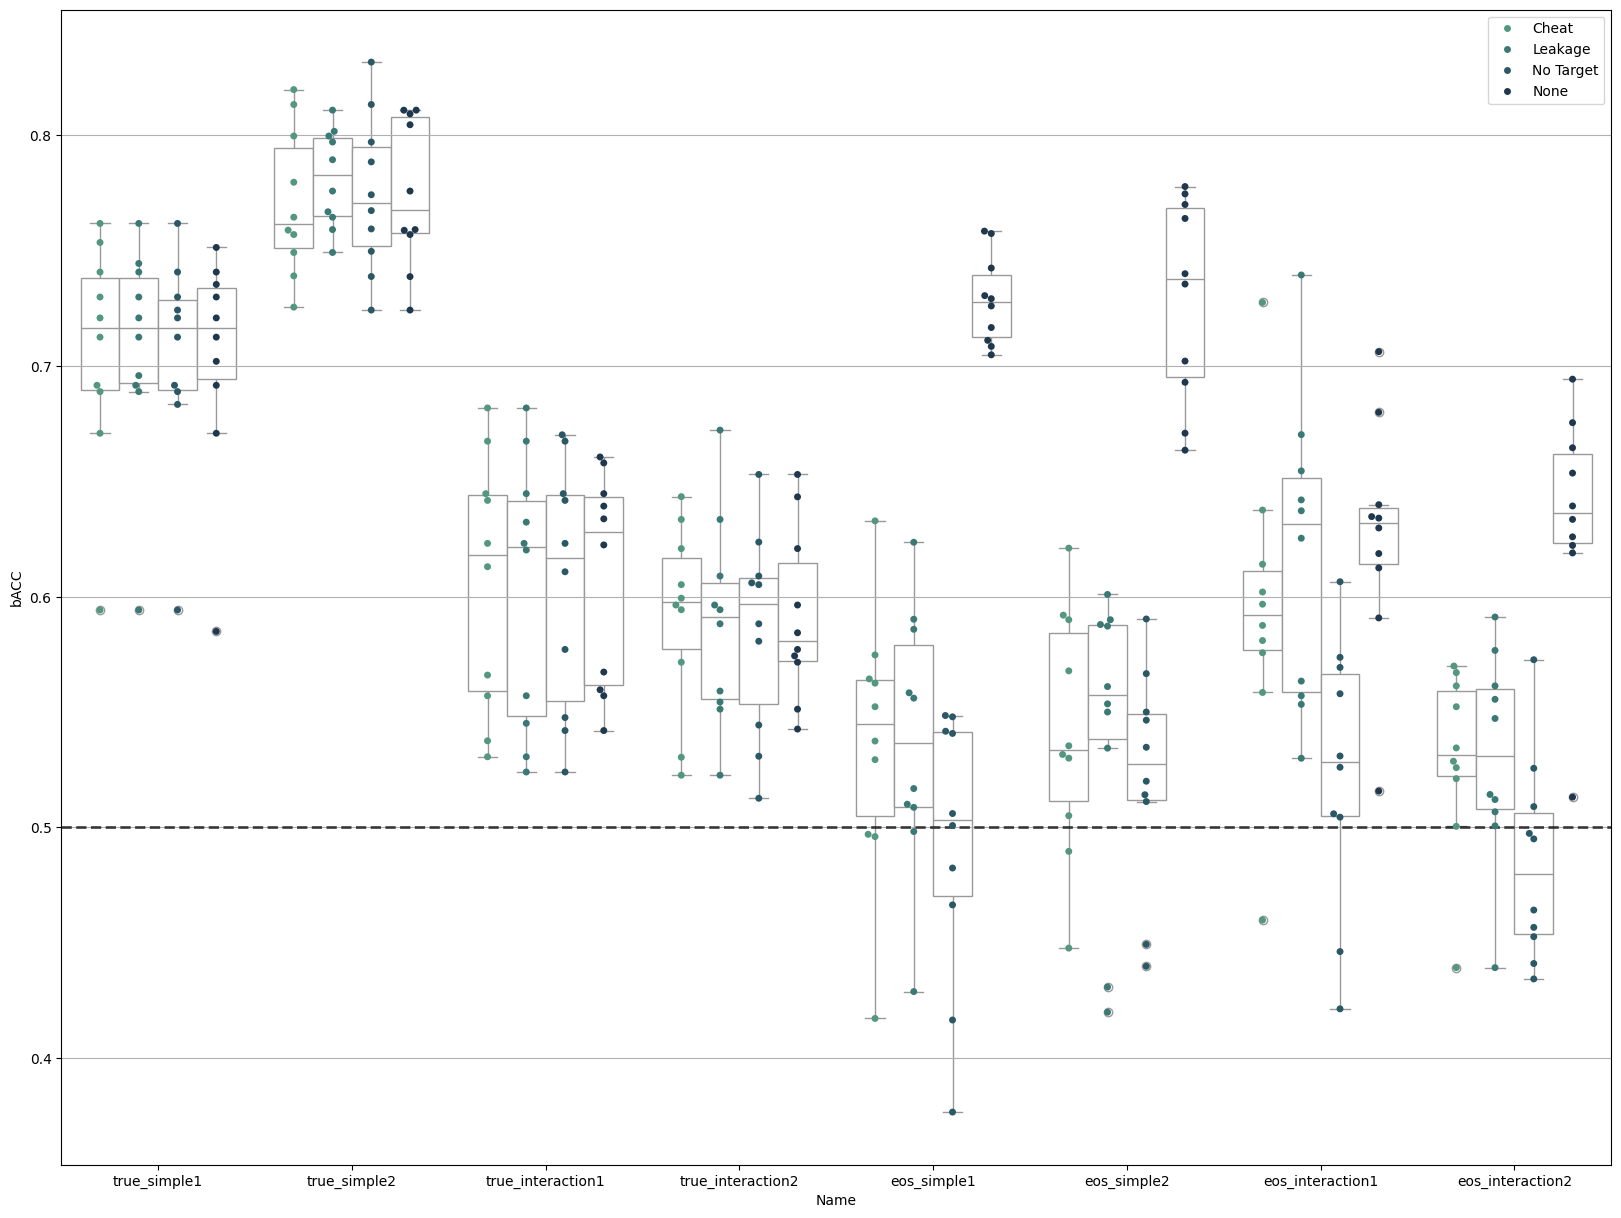

In [38]:
for effect in effects:
    for e_types in effect_types:
        for e_example in effect_examples:
            example = effect + "_" + e_types + e_example
            print("Experiment name: " + example)

            data = datasets[example]

            sites = data["sites"]
            X = data["X"]
            folds = data["folds"]
            folds = pd.Series(folds)
            sites = data["sites"]
            sites = pd.DataFrame(sites)
            sites.replace(
                {"site1": 1, "site2": 2, "site3": 3, "site4": 4, "site5": 5, "site6": 6, "site7": 7, "site8": 8}, inplace=True
            )
            target = data["y"]

            covars = target.ravel().reshape(-1, 1)

            data_cheat = harm_model.fit_transform(X=X, sites=sites, categorical_covariates=covars)
            data_cheat = pd.DataFrame(data_cheat)
            data_cheat["folds"] = data["folds"]

            for fold in folds.unique():
                print("Fold Number: " + str(fold))
                # Train Data
                X = data["X"]
                y = data["y"]
                sites = data["sites"]

                X_train = X[data["folds"] != fold]
                site_train = sites[data["folds"] != fold]
                site_train = pd.DataFrame(site_train)
                site_train.replace(
                    {"site1": 1, "site2": 2, "site3": 3, "site4": 4, "site5": 5, "site6": 6, "site7": 7, "site8": 8}, inplace=True
                )
                y_train = y[data["folds"] != fold]

                # Load "cheat" data
                X_cheat = data_cheat[data_cheat["folds"] != fold]
                X_cheat = X_cheat.drop(columns=["folds"])
                # Train Target
                # Test data
                X_test = X[data["folds"] == fold]
                site_test = sites[data["folds"] == fold]
                site_test = pd.DataFrame(site_test)
                site_test.replace(
                    {"site1": 1, "site2": 2, "site3": 3, "site4": 4, "site5": 5, "site6": 6, "site7": 7, "site8": 8}, inplace=True
                )

                # Get "cheat" data
                X_cheat_test = data_cheat[data_cheat["folds"] == fold]
                X_cheat_test = X_cheat_test.drop(columns=["folds"])
                # Test target
                y_test = y[data["folds"] == fold]

                # None model
                clf.fit(X_train, y_train)
                simple_results.append(
                    [
                        balanced_accuracy_score(y_true=y_test, y_pred=clf.predict(X=X_test)),
                        fold,
                        effect,
                        e_types,
                        e_example,
                        example,
                    ]
                )

                # Cheat
                clf.fit(X_cheat, y_train)
                cheat_results.append(
                    [
                        balanced_accuracy_score(y_true=y_test, y_pred=clf.predict(X=X_cheat_test)),
                        fold,
                        effect,
                        e_types,
                        e_example,
                        example,
                    ]
                )

                # Leakage
                # Extract site numbers from strings
                # Convert to NumPy array
                covars_train = y_train.ravel().reshape(-1, 1)
                harm_data = harm_model.fit_transform(X=X_train, sites=site_train, categorical_covariates=covars_train)
                # Fit the model with the harmonizezd trian
                clf.fit(harm_data, y_train)
                # covars
                # Extract site numbers from strings
                # Convert to NumPy array
                covars_test = y_test.ravel().reshape(-1, 1)
                harm_data_test = harm_model.transform(X=X_test, sites=site_test, categorical_covariates=covars_test)

                leakage_results.append(
                    [
                        balanced_accuracy_score(y_true=y_test, y_pred=clf.predict(X=harm_data_test)),
                        fold,
                        effect,
                        e_types,
                        e_example,
                        example,
                    ]
                )

                # No Target
                # Extract site numbers from strings

                harm_data = harm_model.fit_transform(X=X_train, sites=site_train)
                # Fit the model with the harmonizezd trian
                clf.fit(harm_data, y_train)
                # covars
                # Extract site numbers from strings

                harm_data_test = harm_model.transform(X=X_test, sites=site_test)

                notarget_results.append(
                    [
                        balanced_accuracy_score(y_true=y_test, y_pred=clf.predict(X=harm_data_test)),
                        fold,
                        effect,
                        e_types,
                        e_example,
                        example,
                    ]
                )


# %%
# Save results
results_none = pd.DataFrame(data=simple_results, columns=["bACC", "Fold", "Effect", "Type", "Example", "Name"])
results_none["Method"] = "None"


results_cheat = pd.DataFrame(data=cheat_results, columns=["bACC", "Fold", "Effect", "Type", "Example", "Name"])
results_cheat["Method"] = "Cheat"

results_leakage = pd.DataFrame(data=leakage_results, columns=["bACC", "Fold", "Effect", "Type", "Example", "Name"])
results_leakage["Method"] = "Leakage"

results_notarget = pd.DataFrame(data=notarget_results, columns=["bACC", "Fold", "Effect", "Type", "Example", "Name"])
results_notarget["Method"] = "No Target"

results = pd.concat([results_none, results_cheat, results_leakage, results_notarget])


# %% Plotting resuts

fig, ax = plt.subplots(1, 1, figsize=[20, 15])

harm_methods = ["Cheat", "Leakage", "No Target", "None"]

pal = sbn.cubehelix_palette(len(harm_methods), rot=-0.5, light=0.5, dark=0.2)

sbn.swarmplot(data=results, x="Name", y="bACC", hue="Method", hue_order=harm_methods, dodge=True, ax=ax, palette=pal)

sbn.boxplot(
    data=results,
    color="w",
    zorder=1,
    x="Name",
    y="bACC",
    hue="Method",
    hue_order=harm_methods,
    dodge=True,
    ax=ax,
    palette=["w"] * len(harm_methods),
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[: len(harm_methods)], labels[: len(harm_methods)])
ax.axhline(0.5, lw=2, color="k", ls="--", alpha=0.7, label="Chance level")
plt.grid(axis="y")
plt.show()
# %%